In [1]:
from __future__ import annotations

%matplotlib widget

import logging

import matplotlib.pyplot as plt
import numpy as np
from utils import build_segments

logging.basicConfig(level=logging.INFO)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("rydstate").setLevel(logging.WARNING)

In [2]:
from typing import TYPE_CHECKING

import rydstate

if TYPE_CHECKING:
    from rydstate.rydberg_state import RydbergState

In [3]:
species = "Yb171"
l_r = 0
f_tot = 0.5
nu_range = (0, 150)

basis_oqdt = rydstate.BasisOQDT(species, nu=nu_range, l_r=(l_r, l_r + 1), f_tot=(f_tot, f_tot))
basis_mqdt = rydstate.BasisMQDT(species, nu=nu_range, l_r=(l_r, l_r), f_tot=(f_tot, f_tot))

In [4]:
prefactors = np.linspace(0, 1, 10)
basis_mqdt_scaled = [
    rydstate.BasisMQDT(species, nu=nu_range, l_r=(l_r, l_r), f_tot=(f_tot, f_tot), scale_off_diagonal=scale)
    for scale in prefactors
]

In [5]:
basis_mqdt_scaled[0].states[0]

RydbergStateMQDT(Yb171, nu=2.50167039784145, f_tot=0.5, parity=1, m=NotSet, channels=1, model='Yb171 S F=1/2, 2 < nu < 26')

In [6]:
basis_dict: dict[str, rydstate.basis.BasisBase[RydbergState]] = {}

basis_dict["6sns fc=0"] = (
    basis_oqdt.shallow_copy().filter_states("l_c", 0).filter_states("l_r", l_r).filter_states("f_c", 0)
)

basis_dict["6sns fc=1"] = (
    basis_oqdt.shallow_copy().filter_states("l_c", 0).filter_states("l_r", l_r).filter_states("f_c", 1)
)

basis_dict["6sns lc=1 jc=1/2"] = (
    basis_oqdt.shallow_copy()
    .filter_states("l_r", 1)
    .filter_states("l_c", 1)
    .filter_states("j_c", 1 / 2)
    .filter_states("j_tot", 0)
)

basis_dict["6sns lc=1 jc=3/2"] = (
    basis_oqdt.shallow_copy().filter_states("l_r", 1).filter_states("l_c", 1).filter_states("j_c", 3 / 2)
)

for key in ["4f13 5d 6snl a", "4f13 5d 6snl b", "4f13 5d 6snl c"]:
    basis_dict[key] = basis_oqdt.shallow_copy().filter_states("parity", +1).filter_states_label(key)


basis_dict["full MQDT"] = basis_mqdt

for key, basis in basis_dict.items():
    print(f"{key}: {len(basis.states)} states")
    for i, state in enumerate(basis.states):
        if i >= 3:
            print("  ...\n")
            break
        print(f"  {state}")

6sns fc=0: 155 states
  |Yb171:(6s_1/2,[2.5]s_1/2),f_c=0,F=1/2⟩
  |Yb171:(6s_1/2,[3.5]s_1/2),f_c=0,F=1/2⟩
  |Yb171:(6s_1/2,[4.5]s_1/2),f_c=0,F=1/2⟩
  ...

6sns fc=1: 148 states
  |Yb171:(6s_1/2,[2.5]s_1/2),f_c=1,F=1/2⟩
  |Yb171:(6s_1/2,[3.6]s_1/2),f_c=1,F=1/2⟩
  |Yb171:(6s_1/2,[4.6]s_1/2),f_c=1,F=1/2⟩
  ...

6sns lc=1 jc=1/2: 1 states
  |Yb171:(6p_1/2,[1.8]p_1/2),J=0,F=1/2⟩
6sns lc=1 jc=3/2: 1 states
  |Yb171:(6p_3/2,[1.8]p_3/2),J=0,F=1/2⟩
4f13 5d 6snl a: 1 states
  |Yb171:nu=1.8,4f13 5d 6snl a,F=1/2⟩
4f13 5d 6snl b: 1 states
  |Yb171:nu=1.7,4f13 5d 6snl b,F=1/2⟩
4f13 5d 6snl c: 0 states
full MQDT: 307 states
  0.87*|Yb171:(6s_1/2,[2.5]s_1/2),f_c=0,F=1/2⟩ + 3.7e-06*|Yb171:nu=1.5,4f13 5d 6snl a,F=1/2⟩ - 5.7e-06*|Yb171:(6p_3/2,[1.5]p_3/2),f_c=1,F=1/2⟩ + 7.3e-06*|Yb171:(6p_3/2,[1.5]p_3/2),f_c=2,F=1/2⟩ + 1.5e-06*|Yb171:nu=1.5,4f13 5d 6snl b,F=1/2⟩ - 4.6e-06*|Yb171:(6p_1/2,[1.6]p_1/2),f_c=0,F=1/2⟩ + 7.9e-06*|Yb171:(6p_1/2,[1.6]p_1/2),f_c=1,F=1/2⟩ + 4.9e-06*|Yb171:nu=1.5,4f13 5d 6snl c,F=1/2

In [7]:
overlaps_dict: dict[str, list[float]] = {}

for key, basis in basis_dict.items():
    if isinstance(basis, rydstate.basis.BasisMQDT):
        continue

    overlaps = basis_mqdt.calc_reduced_overlaps(basis)
    overlaps_dict[key] = np.sum(overlaps**2, axis=1).tolist()

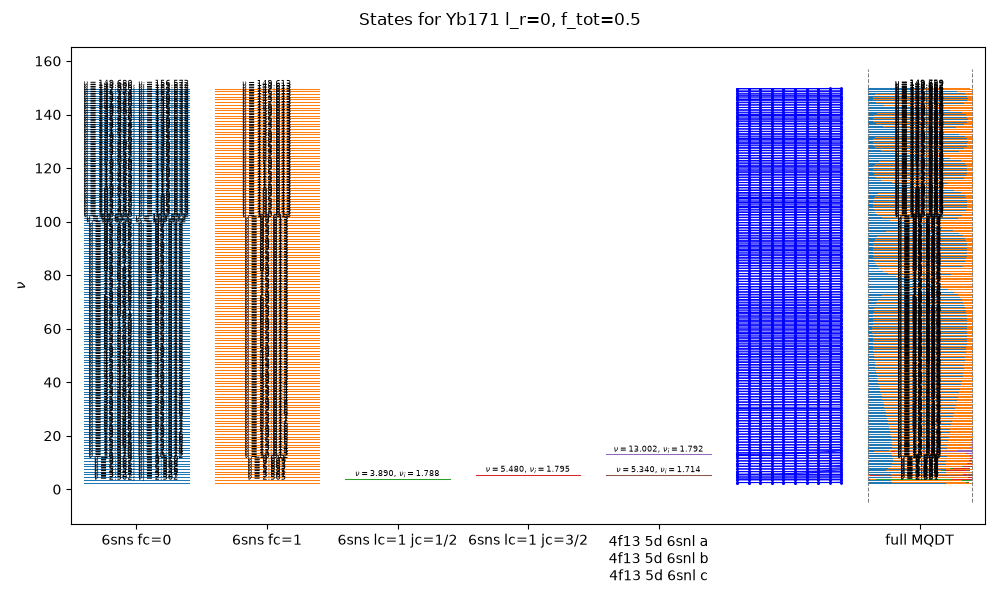

In [8]:
x_loc = {
    # S_05
    "6sns fc=0": 0,
    "6sns fc=1": 1,
    "6sns lc=1 jc=1/2": 2,
    "6sns lc=1 jc=3/2": 3,
    # general
    "4f13 5d 6snl a": 4,
    "4f13 5d 6snl b": 4,
    "4f13 5d 6snl c": 4,
    # mqdt
    "full MQDT": 6,
}


fig, ax = plt.subplots(figsize=(10, 6))

keys = list(basis_dict.keys())
keys_mo_mqdt = [key for key in keys if "MQDT" not in key]

# OQDT states
for i, key in enumerate(keys_mo_mqdt):
    x = x_loc.get(key)
    for state in basis_dict[key].states:
        if np.isinf(state.nu):
            continue

        ax.plot([x - 0.4, x + 0.4], [state.nu, state.nu], color=f"C{i}", lw=0.75)

        # label = rf"$n={state.n}$, $\nu={state.nu:.3f}$"
        label = rf"$\nu={state.nu:.3f}$"
        assert len(state.nui) == 1, f"Expected len(state.nui) == 1, got {len(state.nui)}"
        nui = state.nui[0]
        if not np.isclose(state.nu, nui):
            label += rf", $\nu_{{i}}={nui:.3f}$"
        ax.text(x, state.nu, label, ha="center", va="bottom", fontsize=6, clip_on=True)

# MQDT states
for ids, state in enumerate(basis_mqdt.states):
    if np.isinf(state.nu):
        continue
    overlaps = {key: overlaps_dict[key][ids] for key in keys_mo_mqdt}
    x0 = x_loc["full MQDT"] - 0.4
    for i, key in enumerate(keys_mo_mqdt):
        overlap = overlaps[key]
        x1 = x0 + overlap * 0.8
        ax.plot([x0, x1], [state.nu, state.nu], color=f"C{i}", lw=0.75)
        x0 = x1
    ax.text(x_loc["full MQDT"], state.nu, rf"$\nu={state.nu:.3f}$", ha="center", va="bottom", fontsize=6, clip_on=True)

ylim = ax.get_ylim()
ax.plot([x_loc["full MQDT"] - 0.4, x_loc["full MQDT"] - 0.4], ylim, color="0.5", lw=0.75, ls="--")
ax.plot([x_loc["full MQDT"] + 0.4, x_loc["full MQDT"] + 0.4], ylim, color="0.5", lw=0.75, ls="--")


fig.suptitle(f"States for {species} {l_r=}, {f_tot=}")
xticklabels = {}
for key, x in x_loc.items():
    if x not in xticklabels:
        xticklabels[x] = key
    else:
        xticklabels[x] += f"\n{key}"
ax.set_xticks(list(xticklabels.keys()))
ax.set_xticklabels(list(xticklabels.values()))
ax.set_ylabel(r"$\nu$")

ax.set_xlim(-0.5, max(x_loc.values()) + 0.5)


scaled_nus = [basis.calc_exp_qn("nu") for basis in basis_mqdt_scaled]
for seg in build_segments(scaled_nus):
    xs = np.array([prefactors[i] for i, j in seg]) * 0.8 + x_loc["full MQDT"] - 1 - 0.4
    ys = [scaled_nus[i][j] for i, j in seg]
    ax.plot(xs, ys, color="blue", marker=".", markersize=2, lw=0.75)


plt.tight_layout()
plt.show()